In [1]:
import pandas as pd

df = pd.read_csv('../data/zomato.csv', encoding='latin-1')
cc = pd.read_excel('../data/Country-Code.xlsx')
df = df.merge(cc, on='Country Code', how='left')

print("Shape:", df.shape)
print("\nRestaurants per country:")
print(df['Country'].value_counts())
print("\nColumns:", list(df.columns))
print("\nNull values:")
print(df.isnull().sum())

Shape: (9551, 22)

Restaurants per country:
Country
India             8652
United States      434
United Kingdom      80
Brazil              60
UAE                 60
South Africa        60
New Zealand         40
Turkey              34
Australia           24
Phillipines         22
Indonesia           21
Singapore           20
Qatar               20
Sri Lanka           20
Canada               4
Name: count, dtype: int64

Columns: ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes', 'Country']

Null values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude          

## Dataset Overview
- **Total restaurants:** 9,551 across 15 countries
- **Primary market:** India (8,652 restaurants — 91% of data)
- **Key columns:** Rating, Cost for two, Cuisines, Online Delivery, City, Country
- **Data quality:** Zero nulls in key analytical columns
- **Note:** Non-India countries have small samples (20–434 records) 
  — global comparisons are directional only

In [2]:
# Quick data overview
print(df.describe())
print("\nRating distribution:")
print(df['Rating text'].value_counts())
print("\nOnline delivery breakdown:")
print(df['Has Online delivery'].value_counts())

       Restaurant ID  Country Code    Longitude     Latitude  \
count   9.551000e+03   9551.000000  9551.000000  9551.000000   
mean    9.051128e+06     18.365616    64.126574    25.854381   
std     8.791521e+06     56.750546    41.467058    11.007935   
min     5.300000e+01      1.000000  -157.948486   -41.330428   
25%     3.019625e+05      1.000000    77.081343    28.478713   
50%     6.004089e+06      1.000000    77.191964    28.570469   
75%     1.835229e+07      1.000000    77.282006    28.642758   
max     1.850065e+07    216.000000   174.832089    55.976980   

       Average Cost for two  Price range  Aggregate rating         Votes  
count           9551.000000  9551.000000       9551.000000   9551.000000  
mean            1199.210763     1.804837          2.666370    156.909748  
std            16121.183073     0.905609          1.516378    430.169145  
min                0.000000     1.000000          0.000000      0.000000  
25%              250.000000     1.000000        

In [3]:
# ── CLEANING ──────────────────────────────────────────
# Step 1: Filter out unrated restaurants
df_clean = df[df['Aggregate rating'] > 0].copy()
print(f"Removed {len(df) - len(df_clean)} unrated restaurants")
print(f"Clean dataset: {len(df_clean)} restaurants")

# Step 2: Check cost outlier
print(f"\nCost outliers (>50,000):")
print(df_clean[df_clean['Average Cost for two'] > 50000][
    ['Restaurant Name','City','Country','Average Cost for two']
])

# Step 3: Distribution of ratings now
print(f"\nRating distribution after cleaning:")
print(df_clean['Rating text'].value_counts())

# Step 4: Basic stats on clean data
print(f"\nClean data avg rating: {df_clean['Aggregate rating'].mean():.2f}")
print(f"Clean data avg cost: {df_clean['Average Cost for two'].median():.0f} (median)")

Removed 2148 unrated restaurants
Clean dataset: 7403 restaurants

Cost outliers (>50,000):
                  Restaurant Name       City    Country  Average Cost for two
9276       Noah's Barn Coffeenery    Bandung  Indonesia                150000
9277                    Momo Milk      Bogor  Indonesia                 70000
9278                   Lemongrass      Bogor  Indonesia                250000
9279             Talaga Sampireun    Jakarta  Indonesia                200000
9280                  Toodz House    Jakarta  Indonesia                165000
9281                         OJJU    Jakarta  Indonesia                200000
9282                   Union Deli    Jakarta  Indonesia                200000
9283                         Skye    Jakarta  Indonesia                800000
9284     Satoo - Hotel Shangri-La    Jakarta  Indonesia                800000
9285                        MONKS    Jakarta  Indonesia                250000
9286                        Zenbu    Jakarta  Indon

In [4]:
# ── CURRENCY NOTE + INDIA FOCUS ─────────────────────
# Cost column uses local currency per country
# Indonesia (IDR), India (INR), US (USD) etc — not comparable
# For cost analysis: filter India only (90% of data, same currency)

df_india = df_clean[df_clean['Country'] == 'India'].copy()
df_global = df_clean.copy()  # keep global for rating analysis

print(f"India restaurants: {len(df_india)}")
print(f"Global restaurants: {len(df_global)}")

# Verify India cost makes sense now
print(f"\nIndia median cost: ₹{df_india['Average Cost for two'].median():.0f}")
print(f"India avg rating: {df_india['Aggregate rating'].mean():.2f}")
print(f"\nIndia cities (top 10):")
print(df_india['City'].value_counts().head(10))

India restaurants: 6513
Global restaurants: 7403

India median cost: ₹500
India avg rating: 3.35

India cities (top 10):
City
New Delhi       4048
Gurgaon          890
Noida            696
Faridabad        151
Ghaziabad         23
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64


In [17]:
import sqlite3
import pandas as pd

# ── Fresh database ───────────────────────────────
conn_final = sqlite3.connect(':memory:')
df_india.to_sql('zomato', conn_final, index=False, if_exists='replace')

# ── QUERY 1: Top cities by average rating ────────
print("=" * 60)
print("Q1: TOP CITIES BY AVERAGE RATING")
print("=" * 60)
q1 = pd.read_sql_query("""
    SELECT 
        City,
        COUNT(*) AS total_restaurants,
        ROUND(AVG("Aggregate rating"), 2) AS avg_rating,
        ROUND(AVG("Average Cost for two"), 0) AS avg_cost_inr
    FROM zomato
    GROUP BY City
    HAVING COUNT(*) > 20
    ORDER BY avg_rating DESC
    LIMIT 10
""", conn_final)
print(q1.to_string(index=False))

# ── QUERY 2: Online delivery impact ──────────────
print("\n" + "=" * 60)
print("Q2: ONLINE DELIVERY IMPACT ON RATINGS")
print("=" * 60)
q2 = pd.read_sql_query("""
    SELECT 
        "Has Online delivery",
        COUNT(*) AS restaurant_count,
        ROUND(AVG("Aggregate rating"), 2) AS avg_rating,
        ROUND(AVG("Average Cost for two"), 0) AS avg_cost,
        ROUND(AVG(Votes), 0) AS avg_votes
    FROM zomato
    GROUP BY "Has Online delivery"
""", conn_final)
print(q2.to_string(index=False))

# ── QUERY 3: Top cuisines by rating ──────────────
print("\n" + "=" * 60)
print("Q3: TOP CUISINES BY RATING")
print("=" * 60)
q3 = pd.read_sql_query("""
    SELECT 
        Cuisines,
        COUNT(*) AS restaurant_count,
        ROUND(AVG("Aggregate rating"), 2) AS avg_rating
    FROM zomato
    WHERE Cuisines IS NOT NULL
    AND Cuisines != ''
    GROUP BY Cuisines
    HAVING COUNT(*) > 20
    ORDER BY avg_rating DESC
    LIMIT 10
""", conn_final)
print(q3.to_string(index=False))

# ── QUERY 4: Best value restaurants ──────────────
print("\n" + "=" * 60)
print("Q4: BEST VALUE RESTAURANTS (rating per 100 rupees)")
print("=" * 60)
q4 = pd.read_sql_query("""
    SELECT 
        "Restaurant Name",
        City,
        Cuisines,
        "Aggregate rating",
        "Average Cost for two",
        ROUND(
            CAST("Aggregate rating" AS FLOAT) /
            CAST("Average Cost for two" AS FLOAT) * 100
        , 3) AS value_score
    FROM zomato
    WHERE "Average Cost for two" > 0
    AND "Aggregate rating" > 0
    ORDER BY value_score DESC
    LIMIT 15
""", conn_final)
print(q4.to_string(index=False))

# ── QUERY 5: City expansion score ────────────────
print("\n" + "=" * 60)
print("Q5: CITY EXPANSION SCORE")
print("=" * 60)
q5 = pd.read_sql_query("""
    SELECT 
        City,
        COUNT(*) AS total_restaurants,
        ROUND(AVG("Aggregate rating"), 2) AS avg_rating,
        ROUND(AVG("Average Cost for two"), 0) AS avg_cost,
        SUM(CASE WHEN "Has Online delivery" = 'Yes'
            THEN 1 ELSE 0 END) AS delivery_enabled,
        ROUND(
            100.0 * SUM(CASE WHEN "Has Online delivery" = 'Yes'
            THEN 1 ELSE 0 END) / COUNT(*), 1
        ) AS delivery_pct,
        ROUND(
            AVG("Aggregate rating") *
            (100.0 * SUM(CASE WHEN "Has Online delivery" = 'Yes'
            THEN 1 ELSE 0 END) / COUNT(*)) / 100
        , 3) AS expansion_score
    FROM zomato
    GROUP BY City
    HAVING COUNT(*) > 20
    ORDER BY expansion_score DESC
""", conn_final)
print(q5.to_string(index=False))

print("\n" + "=" * 60)
print("ALL 5 QUERIES COMPLETE ✅")
print("=" * 60)

Q1: TOP CITIES BY AVERAGE RATING
        City  total_restaurants  avg_rating  avg_cost_inr
     Lucknow                 21        4.20         860.0
    Guwahati                 21        4.19         821.0
   Ahmedabad                 21        4.16         857.0
Bhubaneshwar                 21        3.98         679.0
    Amritsar                 21        3.69         481.0
     Gurgaon                890        3.33         798.0
   New Delhi               4048        3.30         692.0
       Noida                696        3.16         630.0
   Ghaziabad                 23        3.10         628.0
   Faridabad                151        3.10         493.0

Q2: ONLINE DELIVERY IMPACT ON RATINGS
Has Online delivery  restaurant_count  avg_rating  avg_cost  avg_votes
                 No              4186        3.34     727.0      162.0
                Yes              2327        3.37     695.0      218.0

Q3: TOP CUISINES BY RATING
                          Cuisines  restaurant_co

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ── Chart settings ───────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
colors = {
    'red':    '#E23744',  # Zomato brand red
    'dark':   '#1A1A2E',
    'gray':   '#6C757D',
    'green':  '#2ECC71',
    'blue':   '#3498DB'
}
print("Chart libraries ready ✅")

Chart libraries ready ✅


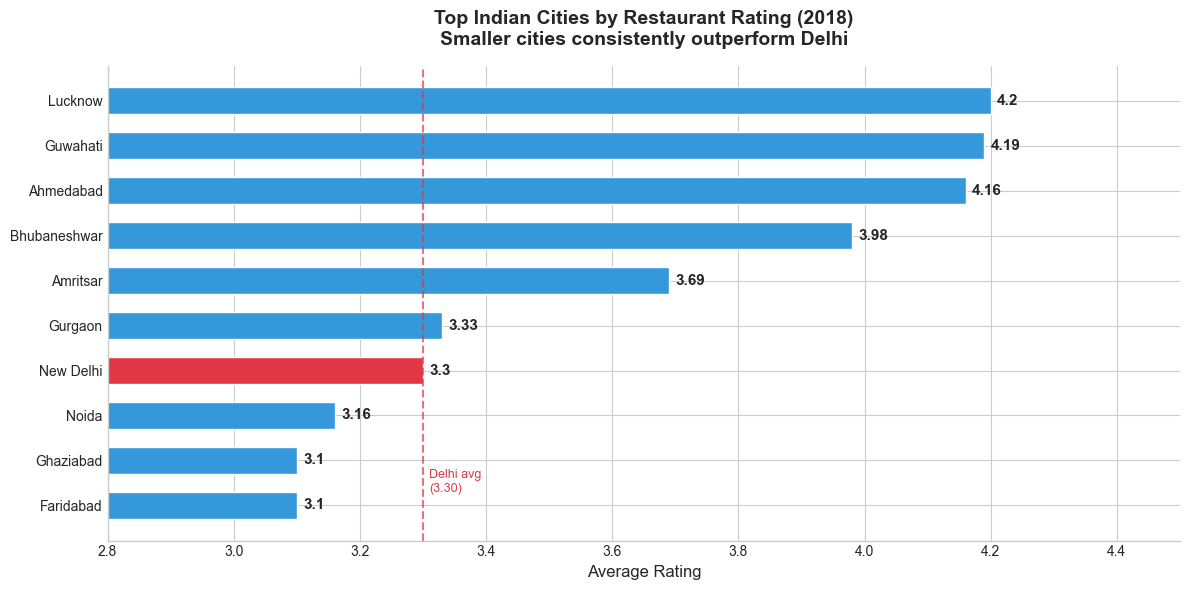

Chart 1 saved ✅


In [20]:
# ── CHART 1: Top cities by average rating ────────
# Finding: Smaller cities outperform Delhi in quality

fig, ax = plt.subplots(figsize=(12, 6))

# Data from Q1
cities = ['Lucknow', 'Guwahati', 'Ahmedabad', 'Bhubaneshwar',
          'Amritsar', 'Gurgaon', 'New Delhi', 'Noida',
          'Ghaziabad', 'Faridabad']
ratings = [4.20, 4.19, 4.16, 3.98, 3.69,
           3.33, 3.30, 3.16, 3.10, 3.10]

# Color Delhi differently to highlight the finding
bar_colors = [colors['red'] if city == 'New Delhi' 
              else colors['blue'] for city in cities]

bars = ax.barh(cities[::-1], ratings[::-1], 
               color=bar_colors[::-1], edgecolor='white',
               height=0.6)

# Add value labels on bars
for bar, rating in zip(bars, ratings[::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{rating}', va='center', fontsize=11, fontweight='bold')

# Add reference line at Delhi's rating
ax.axvline(x=3.30, color=colors['red'], 
           linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(3.31, 0.3, 'Delhi avg\n(3.30)', 
        color=colors['red'], fontsize=9)

# Formatting
ax.set_xlabel('Average Rating', fontsize=12)
ax.set_title('Top Indian Cities by Restaurant Rating (2018)\n'
             'Smaller cities consistently outperform Delhi', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(2.8, 4.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../dashboard/screenshots/chart1_cities_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✅")

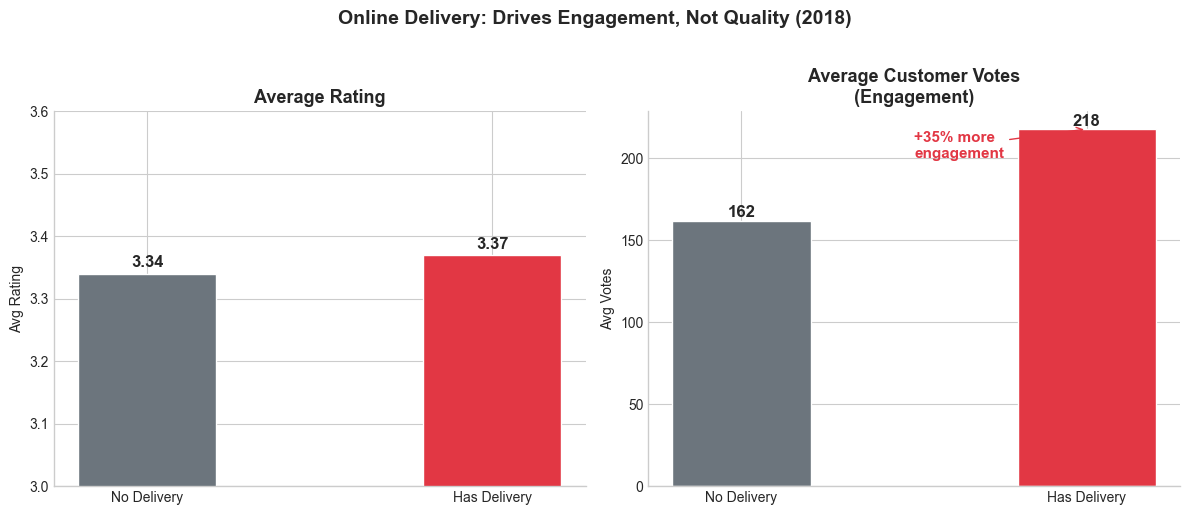

Chart 2 saved ✅


In [21]:
# ── CHART 2: Online delivery impact ──────────────
# Finding: Delivery = more engagement, not better food

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left chart — avg rating comparison
categories = ['No Delivery', 'Has Delivery']
ratings = [3.34, 3.37]
votes = [162, 218]

bars1 = axes[0].bar(categories, ratings,
                    color=[colors['gray'], colors['red']],
                    width=0.4, edgecolor='white')
axes[0].set_ylim(3.0, 3.6)
axes[0].set_title('Average Rating', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Rating')
for bar, val in zip(bars1, ratings):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val}', ha='center', fontweight='bold', fontsize=12)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right chart — avg votes comparison
bars2 = axes[1].bar(categories, votes,
                    color=[colors['gray'], colors['red']],
                    width=0.4, edgecolor='white')
axes[1].set_title('Average Customer Votes\n(Engagement)', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Votes')
for bar, val in zip(bars2, votes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 f'{val}', ha='center', fontweight='bold', fontsize=12)

# Add % difference annotation
axes[1].annotate('+35% more\nengagement',
                 xy=(1, 218), xytext=(0.5, 200),
                 fontsize=11, color=colors['red'],
                 fontweight='bold',
                 arrowprops=dict(arrowstyle='->', 
                                 color=colors['red']))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Online Delivery: Drives Engagement, Not Quality (2018)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../dashboard/screenshots/chart2_delivery_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved ✅")

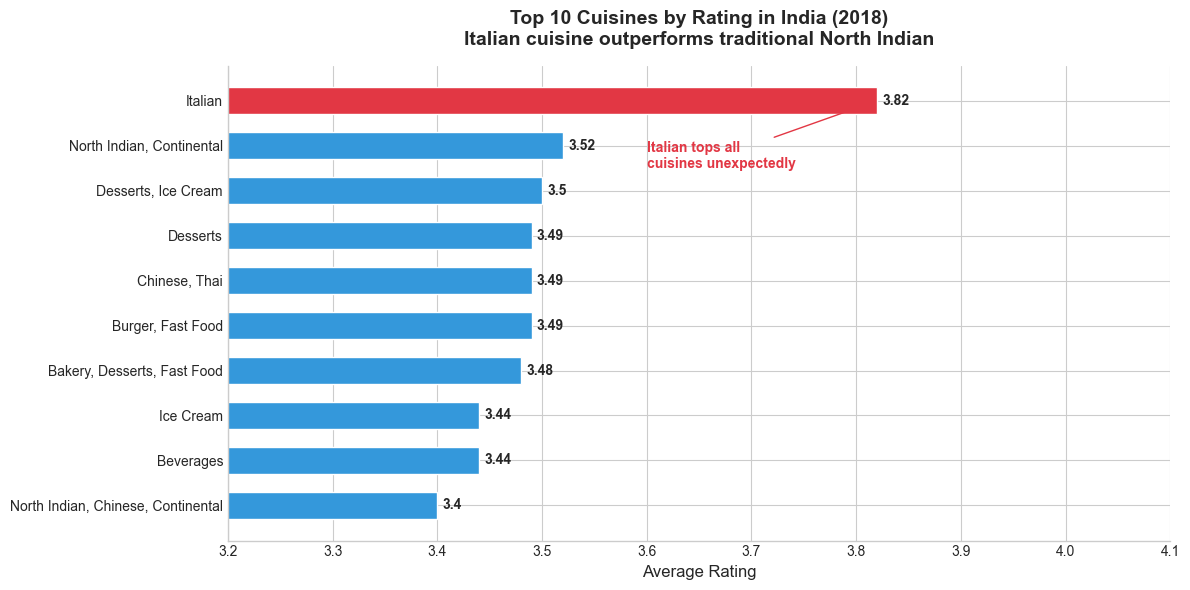

Chart 3 saved ✅


In [22]:
# ── CHART 3: Top cuisines by rating ──────────────
# Finding: Italian tops ratings, North Indian lower than expected

fig, ax = plt.subplots(figsize=(12, 6))

cuisines = ['Italian', 'North Indian, Continental',
            'Desserts, Ice Cream', 'Desserts',
            'Chinese, Thai', 'Burger, Fast Food',
            'Bakery, Desserts, Fast Food', 'Ice Cream',
            'Beverages', 'North Indian, Chinese, Continental']
ratings = [3.82, 3.52, 3.50, 3.49, 3.49, 3.49, 3.48, 3.44, 3.44, 3.40]

# Color Italian differently — top finding
bar_colors = [colors['red'] if i == 0 
              else colors['blue'] for i in range(len(cuisines))]

bars = ax.barh(cuisines[::-1], ratings[::-1],
               color=bar_colors[::-1],
               height=0.6, edgecolor='white')

# Value labels
for bar, rating in zip(bars, ratings[::-1]):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{rating}', va='center',
            fontsize=10, fontweight='bold')

# Highlight annotation
ax.annotate('Italian tops all\ncuisines unexpectedly',
            xy=(3.82, 9), xytext=(3.60, 7.5),
            fontsize=10, color=colors['red'],
            fontweight='bold',
            arrowprops=dict(arrowstyle='->',
                           color=colors['red']))

ax.set_xlabel('Average Rating', fontsize=12)
ax.set_title('Top 10 Cuisines by Rating in India (2018)\n'
             'Italian cuisine outperforms traditional North Indian',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(3.2, 4.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../dashboard/screenshots/chart3_cuisines_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved ✅")

/var/folders/j6/tk5thy_169v8ljv23q04f9200000gn/T/ipykernel_96980/2892478134.py:52: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j6/tk5thy_169v8ljv23q04f9200000gn/T/ipykernel_96980/2892478134.py:53: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('chart4_value_restaurants.png', dpi=150, bbox_inches='tight')
/Users/jitender4497/Desktop/Zomato_data_analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


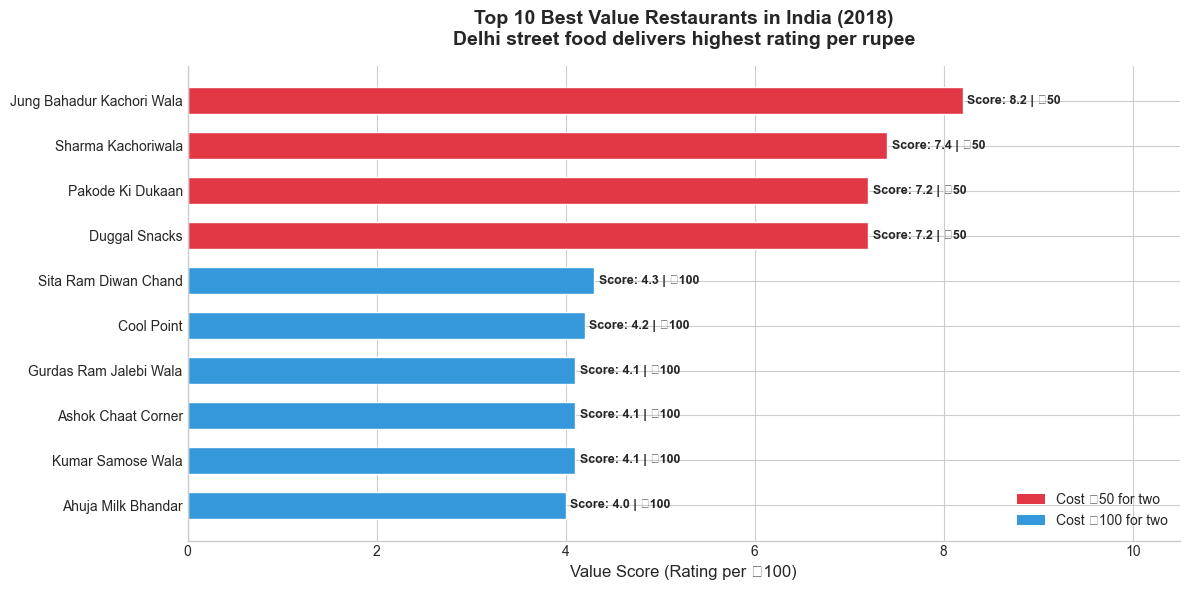

Chart 4 saved ✅


In [23]:
# ── CHART 4: Best value restaurants ──────────────
# Finding: Delhi street food = unbeatable value

fig, ax = plt.subplots(figsize=(12, 6))

restaurants = [
    'Jung Bahadur Kachori Wala',
    'Sharma Kachoriwala',
    'Pakode Ki Dukaan',
    'Duggal Snacks',
    'Sita Ram Diwan Chand',
    'Cool Point',
    'Gurdas Ram Jalebi Wala',
    'Ashok Chaat Corner',
    'Kumar Samose Wala',
    'Ahuja Milk Bhandar'
]
value_scores = [8.2, 7.4, 7.2, 7.2, 4.3, 4.2, 4.1, 4.1, 4.1, 4.0]
costs = [50, 50, 50, 50, 100, 100, 100, 100, 100, 100]

# Color by cost
bar_colors = [colors['red'] if c == 50 
              else colors['blue'] for c in costs]

bars = ax.barh(restaurants[::-1], value_scores[::-1],
               color=bar_colors[::-1],
               height=0.6, edgecolor='white')

# Value labels
for bar, score, cost in zip(bars, value_scores[::-1], costs[::-1]):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'Score: {score} | ₹{cost}',
            va='center', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors['red'], label='Cost ₹50 for two'),
    Patch(facecolor=colors['blue'], label='Cost ₹100 for two')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.set_xlabel('Value Score (Rating per INR 100)', fontsize=12)
ax.set_title('Top 10 Best Value Restaurants in India (2018)\n'
             'Delhi street food delivers highest rating per rupee',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 10.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../dashboard/screenshots/chart4_value_restaurants.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved ✅")

/var/folders/j6/tk5thy_169v8ljv23q04f9200000gn/T/ipykernel_96980/3638824887.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cities, rotation=30, ha='right')


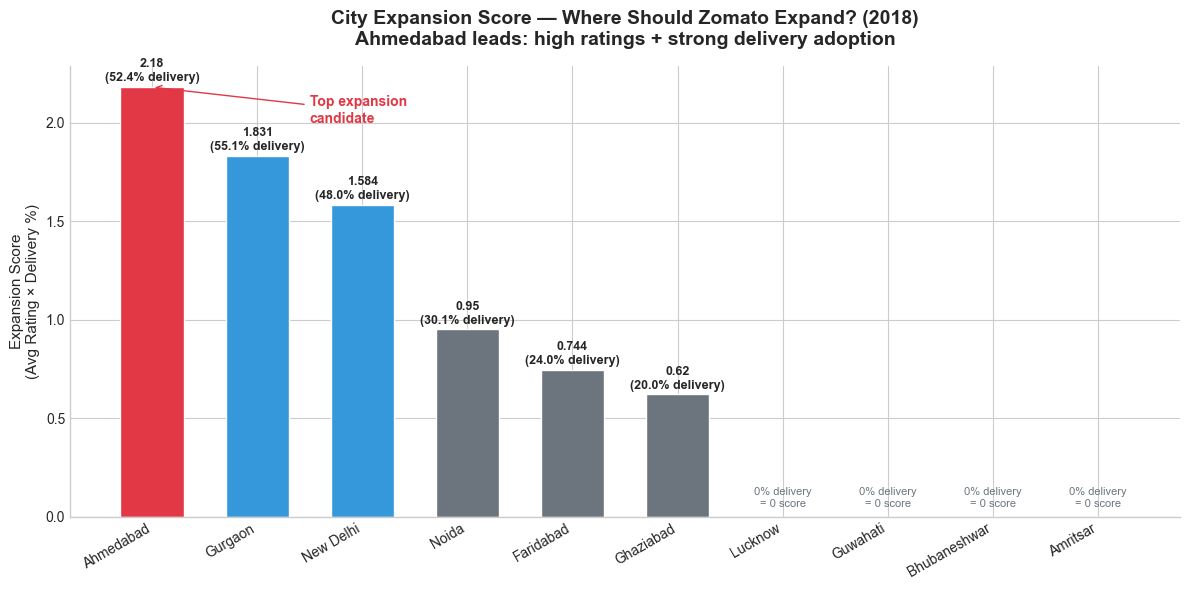

Chart 5 saved ✅


In [24]:
# ── CHART 5: City expansion score ────────────────
# Finding: Ahmedabad = best expansion candidate

fig, ax = plt.subplots(figsize=(12, 6))

cities = ['Ahmedabad', 'Gurgaon', 'New Delhi', 
          'Noida', 'Faridabad', 'Ghaziabad',
          'Lucknow', 'Guwahati', 'Bhubaneshwar', 'Amritsar']
expansion_scores = [2.180, 1.831, 1.584, 
                    0.950, 0.744, 0.620,
                    0.000, 0.000, 0.000, 0.000]
delivery_pct = [52.4, 55.1, 48.0, 
                30.1, 24.0, 20.0,
                0.0, 0.0, 0.0, 0.0]

# Color top 3 differently
bar_colors = [colors['red'] if i == 0 
              else colors['blue'] if i < 3 
              else colors['gray'] 
              for i in range(len(cities))]

bars = ax.bar(cities, expansion_scores,
              color=bar_colors, edgecolor='white', width=0.6)

# Value labels
for bar, score, dpct in zip(bars, expansion_scores, delivery_pct):
    if score > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.03,
                f'{score}\n({dpct}% delivery)',
                ha='center', fontsize=9, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2,
                0.05, '0% delivery\n= 0 score',
                ha='center', fontsize=8,
                color=colors['gray'])

# Annotation
ax.annotate('Top expansion\ncandidate',
            xy=(0, 2.180), xytext=(1.5, 2.0),
            fontsize=10, color=colors['red'],
            fontweight='bold',
            arrowprops=dict(arrowstyle='->',
                           color=colors['red']))

ax.set_ylabel('Expansion Score\n(Avg Rating × Delivery %)', fontsize=11)
ax.set_title('City Expansion Score — Where Should Zomato Expand? (2018)\n'
             'Ahmedabad leads: high ratings + strong delivery adoption',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../dashboard/screenshots/chart5_expansion_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved ✅")

In [ ]:
# ── CHART 6: HERO CHART — Rating vs Cost bubble map ──
# Finding: Value quadrants — where to eat smart

import plotly.express as px
import plotly.graph_objects as go

# City level data
city_data = pd.read_sql_query("""
    SELECT 
        City,
        COUNT(*) AS total,
        ROUND(AVG("Aggregate rating"), 2) AS avg_rating,
        ROUND(AVG("Average Cost for two"), 0) AS avg_cost,
        ROUND(100.0 * SUM(CASE WHEN "Has Online delivery" = 'Yes' 
            THEN 1 ELSE 0 END) / COUNT(*), 1) AS delivery_pct
    FROM zomato
    GROUP BY City
    HAVING COUNT(*) > 20
    ORDER BY total DESC
""", conn_final)

fig = px.scatter(
    city_data,
    x='avg_cost',
    y='avg_rating',
    size='total',
    color='delivery_pct',
    hover_name='City',
    hover_data={
        'avg_cost': True,
        'avg_rating': True,
        'total': True,
        'delivery_pct': True
    },
    color_continuous_scale='RdYlGn',
    size_max=60,
    title='Zomato India — City Intelligence Map (2018)<br>'
          '<sup>Bubble size = restaurant count | '
          'Color = delivery adoption %</sup>',
    labels={
        'avg_cost': 'Avg Cost for Two (Local Currency)',
        'avg_rating': 'Average Rating',
        'delivery_pct': 'Delivery %',
        'total': 'Restaurants'
    }
)

# Add quadrant lines
avg_rating_line = city_data['avg_rating'].mean()
avg_cost_line = city_data['avg_cost'].mean()

fig.add_hline(y=avg_rating_line, line_dash='dash',
              line_color='gray', opacity=0.5)
fig.add_vline(x=avg_cost_line, line_dash='dash',
              line_color='gray', opacity=0.5)

# Quadrant labels
fig.add_annotation(x=200, y=4.1,
    text='Hidden Gems<br>(High quality, Low cost)',
    showarrow=False, font=dict(size=11, color='green'),
    bgcolor='rgba(255,255,255,0.8)')

fig.add_annotation(x=900, y=4.1,
    text='Premium Quality<br>(High quality, High cost)',
    showarrow=False, font=dict(size=11, color='blue'),
    bgcolor='rgba(255,255,255,0.8)')

fig.add_annotation(x=200, y=3.1,
    text='Budget Bets<br>(Low quality, Low cost)',
    showarrow=False, font=dict(size=11, color='orange'),
    bgcolor='rgba(255,255,255,0.8)')

fig.add_annotation(x=900, y=3.1,
    text='Avoid<br>(Low quality, High cost)',
    showarrow=False, font=dict(size=11, color='red'),
    bgcolor='rgba(255,255,255,0.8)')

fig.update_layout(
    height=600,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=12),
    coloraxis_colorbar=dict(title='Delivery %')
)

fig.update_xaxes(showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

fig.write_html('../dashboard/screenshots/chart6_city_intelligence_map.html')
print('Chart 6 saved ✅')


## Key Findings — Zomato India Restaurant Analysis (2018)

**Finding 1:** Lucknow (4.20), Guwahati (4.19), Ahmedabad (4.16) 
outperform New Delhi (3.30) despite Delhi having 190x more restaurants.

**Finding 2:** Online delivery drives engagement (+35% more votes) 
but barely improves ratings (+0.03) — visibility over quality.

**Finding 3:** Italian cuisine (3.82) tops all cuisines — 
outperforming traditional North Indian (3.40).

**Finding 4:** Best value dining = Delhi street food. 
Jung Bahadur Kachori Wala: 4.1 rating at just Rs.50 for two.

**Finding 5:** Ahmedabad is top expansion candidate — 
highest ratings + 52% delivery adoption combined.

## Business Recommendation
Zomato should prioritise delivery partner onboarding in 
Lucknow and Guwahati — high quality restaurants already exist, 
delivery infrastructure is completely missing.

In [ ]:
# Export analysis outputs
df_india.to_csv('../data/zomato_india_clean.csv', index=False)
df_global.to_csv('../data/zomato_global_clean.csv', index=False)
q1.to_csv('../data/q1_cities_rating.csv', index=False)
q2.to_csv('../data/q2_delivery_impact.csv', index=False)
q3.to_csv('../data/q3_cuisines_rating.csv', index=False)
q4.to_csv('../data/q4_value_restaurants.csv', index=False)
q5.to_csv('../data/q5_expansion_score.csv', index=False)
print("All files exported ✅")
